In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np

# Embeddings
drug_emb = np.load("Data/drug_chemberta_embeddings.npy")
# adr_emb = np.load("Data/adr_bert_embeddings.npy")

# Names (for indexing)
cid_df = pd.read_csv("Data/drug_ids.csv")       # column: CID
adr_names = pd.read_csv("Data/adr_names.csv")    # column: ADR

# Positive drug-ADR pairs
df_meddra_all_se = pd.read_csv("Data/meddra_all_se.tsv", sep="\t", header=None)
print(df_meddra_all_se.head())
df_meddra_all_se.columns = ["CID", "STITCH_CID", "UMLS_ID", "Source", "Noname","ADR"]
df_meddra_all_se["new_CID"] = df_meddra_all_se["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)
df_meddra_all_indications = pd.read_csv("Data/meddra_all_indications.tsv", sep="\t", header=None,
                 names=["CID", "UMLS_ID", "text", "name", "name2","ID", "name4"])

df_meddra_all_indications["new_CID"] = df_meddra_all_indications["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)

# CUI_list = df_meddra_all_se['UMLS_ID'].unique()
# drug_list = df_meddra_all_se["CID"].unique()

ADR_CUI = pd.read_csv("Data/ADR_CUI_TO_NAME.csv", header=None,
                 names=["CUI","ADR_NAME"])
df_adr_UMLS = pd.read_csv("Data/ADR_Path_Lesk_sim.csv", sep=",", header=None)

# df_meddra_all_se

              0             1         2    3         4                      5
0  CID100000085  CID000010917  C0000729  LLT  C0000729       Abdominal cramps
1  CID100000085  CID000010917  C0000729   PT  C0000737         Abdominal pain
2  CID100000085  CID000010917  C0000737  LLT  C0000737         Abdominal pain
3  CID100000085  CID000010917  C0000737   PT  C0687713  Gastrointestinal pain
4  CID100000085  CID000010917  C0000737   PT  C0000737         Abdominal pain


In [2]:
cid_to_index = {cid: i for i, cid in enumerate(cid_df["CID"].tolist())}
cui_to_index = {adr: i for i, adr in enumerate(ADR_CUI["CUI"].tolist())}



In [3]:

adr_counts = df_meddra_all_se["UMLS_ID"].value_counts()


rare_adr = adr_counts[adr_counts <= 5].index.tolist()
common_adr = adr_counts[adr_counts > 5].index.tolist()

print("Rare ADRs:", len(rare_adr))
print("Common ADRs:", len(common_adr))


Rare ADRs: 2661
Common ADRs: 3207


In [4]:
positive_data = []
# y = []
count = 0
adr_UMLS = df_adr_UMLS.to_numpy()
# (label = 1)
for _, row in df_meddra_all_se.iterrows():
    cid = row["new_CID"]
    adr = row["UMLS_ID"]

    i = cid_to_index.get(cid)
    j = cui_to_index.get(adr)

    if adr in common_adr:
      if i is not None and j is not None and i < drug_emb.shape[0] :#and count != 147467: #only use 50% of data
        # ADR = df_adr_UMLS.iloc[j].tolist()
        count += 1
        emb = np.concatenate([drug_emb[i], adr_UMLS[j]])
        positive_data.append(emb)
        # y.append(1)




In [5]:
import ast
negative_data = []
count = 0

for index, row in df_meddra_all_indications.iterrows():
    # if(count == 0):
        if row['new_CID'] in cid_to_index.keys() and (row['UMLS_ID'] in cui_to_index.keys()) and row['UMLS_ID'] not in rare_adr:
            cid = row["new_CID"]
            adr = row["UMLS_ID"]
            i = cid_to_index.get(cid)
            j = cui_to_index.get(adr)
            if( j < adr_UMLS.shape[0] and i < drug_emb.shape[0]):
                emb = np.concatenate([drug_emb[i], adr_UMLS[j]])    
            # emb = np.concatenate([drug_row, ADR])
            # print(emb[1:100])
            negative_data.append(emb) 

In [6]:
(23128, 294935)
len(negative_data), len(positive_data)

(22140, 287565)

In [7]:
import random
P = positive_data.copy()
N = negative_data.copy()

n = len(N)//10
indices = np.random.choice(len(N), n, replace=False)
test_negative_data = [N[i] for i in indices]
for i in sorted(indices, reverse=True):
    del N[i]
    
indices = np.random.choice(len(P), n, replace=False)
test_positive_data = [P[i] for i in indices]
for i in sorted(indices, reverse=True):
    del P[i]

test_data = test_positive_data + test_negative_data
test_label = [1]*len(test_positive_data) + [0]*len(test_negative_data)

len(N), len(negative_data)

(19926, 22140)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [9]:
P_size = len(P)
N_size = len(N)
if(P_size % N_size < N_size/2):
    n = P_size % N_size + N_size
    print("YES")
    
else:
    n = P_size % N_size
indices = np.random.choice(len(P), n, replace=False)
train_i_positive_data = [P[i] for i in indices]
for i in sorted(indices, reverse=True):
    del P[i]
    
train_i_label = [1]*len(train_i_positive_data) + [0]*len(N)
train_i = train_i_positive_data + N
rf_models = [] 



X_train = train_i
y_train = train_i_label
#train an RF
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_models.append(rf)

YES


In [10]:
y_pred = rf_models[0].predict(test_data)
    
all_preds = []
all_preds.append(y_pred)

print("Accuracy:", accuracy_score(test_label, y_pred))
print("Confusion Matrix:\n", confusion_matrix(test_label, y_pred))
print("Classification Report:\n", classification_report(test_label, y_pred))

Accuracy: 0.9193766937669376
Confusion Matrix:
 [[2104  110]
 [ 247 1967]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      2214
           1       0.95      0.89      0.92      2214

    accuracy                           0.92      4428
   macro avg       0.92      0.92      0.92      4428
weighted avg       0.92      0.92      0.92      4428



In [11]:
count = 1
while len(P)!=0:
    n = N_size
    indices = np.random.choice(len(P), n, replace=False)
    train_i_positive_data = [P[i] for i in indices]
    for i in sorted(indices, reverse=True):
        del P[i]
    train_i_label = [1]*len(train_i_positive_data) + [0]*len(N)
    train_i = train_i_positive_data + N
    X_train = train_i
    y_train = train_i_label
    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    rf_models.append(rf)
    print(f"{count}: size:",len(train_i))
    count += 1

1: size: 39852
2: size: 39852
3: size: 39852
4: size: 39852
5: size: 39852
6: size: 39852
7: size: 39852
8: size: 39852
9: size: 39852
10: size: 39852
11: size: 39852
12: size: 39852
13: size: 39852


In [12]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    matthews_corrcoef
)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


In [13]:

results = []

for i, model in enumerate(rf_models):
    y_pred = model.predict(test_data)
    y_proba = None
    # بررسی اینکه آیا مدل تابع predict_proba دارد
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(test_data)[:, 1]  # احتمال کلاس مثبت
    
    # برخی معیارها فقط اگر احتمال داشته باشیم قابل محاسبه‌اند
    auc_roc = roc_auc_score(test_label, y_proba) 
    auc_pr = average_precision_score(test_label, y_proba) 
    
    acc = accuracy_score(test_label, y_pred)
    prec = precision_score(test_label, y_pred)
    rec = recall_score(test_label, y_pred)
    f1 = f1_score(test_label, y_pred)
    sp = specificity_score(test_label, y_pred)
    mcc = matthews_corrcoef(test_label, y_pred)
    
    results.append({
        'Model #': i + 1,
        'AUC-ROC': round(auc_roc, 3),
        'AUC-PR': round(auc_pr, 3),
        'ACC': round(acc, 3),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1-score': round(f1, 3),
        'SP': round(sp, 3),
        'MCC': round(mcc, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)


    Model #  AUC-ROC  AUC-PR    ACC  Precision  Recall  F1-score     SP    MCC
0         1    0.969   0.973  0.919      0.947   0.888     0.917  0.950  0.840
1         2    0.965   0.970  0.906      0.953   0.855     0.901  0.958  0.816
2         3    0.966   0.968  0.913      0.959   0.862     0.908  0.963  0.830
3         4    0.964   0.969  0.905      0.954   0.852     0.900  0.959  0.815
4         5    0.965   0.970  0.905      0.960   0.846     0.899  0.964  0.816
5         6    0.967   0.972  0.911      0.965   0.852     0.905  0.969  0.827
6         7    0.967   0.971  0.914      0.961   0.862     0.909  0.965  0.832
7         8    0.966   0.969  0.905      0.958   0.846     0.899  0.963  0.815
8         9    0.965   0.969  0.908      0.957   0.855     0.903  0.961  0.821
9        10    0.966   0.969  0.904      0.956   0.848     0.899  0.961  0.814
10       11    0.964   0.966  0.899      0.951   0.841     0.893  0.957  0.804
11       12    0.967   0.972  0.910      0.954   0.8

In [14]:
from scipy.stats import mode  
all_probas = []

for model in rf_models:
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(test_data)[:, 1]  # احتمال کلاس مثبت
        all_probas.append(proba)
    else:
        # اگر مدلی predict_proba نداشت، مثلا میتونی پیش‌بینی 0/1 رو استفاده کنی (کمک‌کننده نیست برای AUC)
        proba = model.predict(test_data)
        all_probas.append(proba)

all_probas = np.array(all_probas)
mean_proba = np.mean(all_probas, axis=0)  # میانگین احتمال

# 2. پیش‌بینی Voting اکثریت (برای سایر معیارها)


all_preds = []
for model in rf_models:
    preds = model.predict(test_data)
    all_preds.append(preds)

all_preds = np.array(all_preds)
final_preds, _ = mode(all_preds, axis=0)
final_preds = final_preds.flatten()

# 3. محاسبه معیارها

auc_roc = roc_auc_score(test_label, mean_proba)
auc_pr = average_precision_score(test_label, mean_proba)

acc = accuracy_score(test_label, final_preds)
prec = precision_score(test_label, final_preds)
rec = recall_score(test_label, final_preds)
f1 = f1_score(test_label, final_preds)
sp = specificity_score(test_label, final_preds)
mcc = matthews_corrcoef(test_label, final_preds)

# 4. چاپ نتایج
print(f"AUC-ROC: {auc_roc:.3f}")
print(f"AUC-PR: {auc_pr:.3f}")
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Specificity (SP): {sp:.3f}")
print(f"MCC: {mcc:.3f}")
print("\nClassification Report:")
print(classification_report(test_label, final_preds))
new_row = {
    'Model #': "Voting Result",
    'AUC-ROC': round(auc_roc, 3),
    'AUC-PR': round(auc_pr, 3),
    'ACC': round(acc, 3),
    'Precision': round(prec, 3),
    'Recall': round(rec, 3),
    'F1-score': round(f1, 3),
    'SP': round(sp, 3),
    'MCC': round(mcc, 3)
}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)


AUC-ROC: 0.976
AUC-PR: 0.979
Accuracy: 0.911
Precision: 0.970
Recall: 0.848
F1-score: 0.905
Specificity (SP): 0.974
MCC: 0.828

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      2214
           1       0.97      0.85      0.90      2214

    accuracy                           0.91      4428
   macro avg       0.92      0.91      0.91      4428
weighted avg       0.92      0.91      0.91      4428



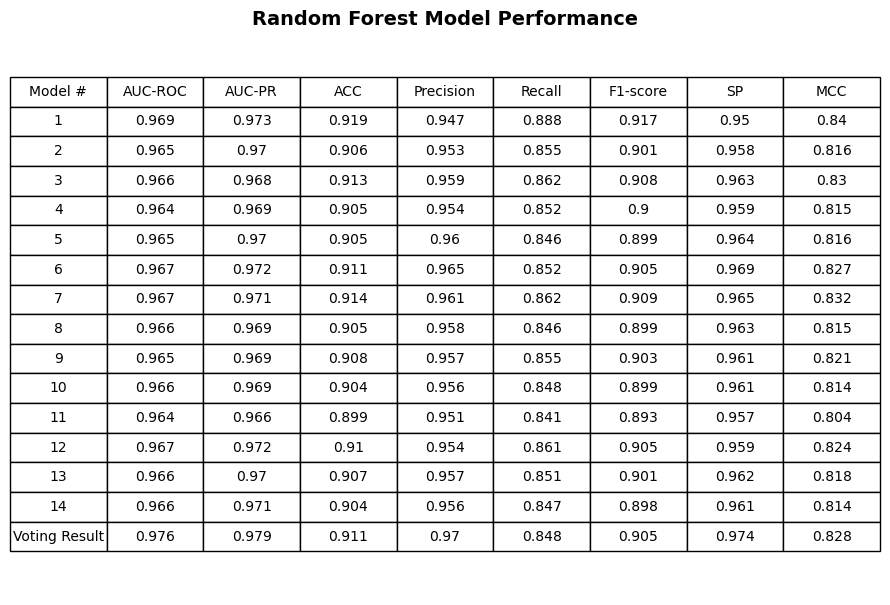

In [15]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(9, len(results_df)*0.41))


ax.axis('off')
table = ax.table(cellText=results_df.values,
                 colLabels=results_df.columns,
                 cellLoc='center',
                 loc='center')


table.scale(1, 1.5) 
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Random Forest Model Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
